## Notebook to learn to play with tif images

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt

import experiment_settings
import build_model
import train_model
import build_data
import methods
import read_landsat

import tensorflow as tf


In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")

# tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
print(tf.config.list_physical_devices("GPU"))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# GET SETTINGS
EXP_NAME = "exp3"
settings = experiment_settings.get_settings(EXP_NAME)
settings["mode"] = "training"
display(settings)

# SET RANDOM SEEDS
np.random.seed(settings["rng_seed"])
random.seed(settings["rng_seed"])
tf.random.set_seed(settings["rng_seed"])


{'mode': 'training',
 'training_years': (2015, 2016, 2017, 2018, 2019),
 'inference_years': (2020,),
 'training_region': (-90, 90, -180, 180),
 'inference_region': (-90, 90, -180, 180),
 'channels': (1, 2, 3, 4, 5, 6),
 'scene_width': 11,
 'nbatches': (750, 25),
 'batches_per_epoch': 750,
 'rng_seed': 33,
 'layers_units': (64, 128, 128, 128, 128),
 'kernel_size': 3,
 'max_pool_stride': (2, 2),
 'dense_units': 32,
 'loss': 'DenseDualWeightMSE',
 'loss_params': (0.2, 50.0),
 'kluge_value_for_zero': 0.0,
 'kluge_value_for_one': 0.0,
 'aug_randomflip': True,
 'input_noise': 10,
 'sample_weights_alpha': 15.0,
 'subsample': True,
 'learning_rate': 0.001,
 'dropout': 0.1,
 'patience': 3,
 'batch_size': 32,
 'max_epochs': 1000,
 'early_stopping': True,
 'pickup_where_leftoff': False,
 'save_best_only': True,
 'exp_name': 'exp3',
 'tile_len_deg': 1.0,
 'landsat_pixel_to_deg': 0.00026949,
 'landsat_to_hfi_ratio': 10.0,
 'scene_width_landsat': 110}

In [4]:
# LOAD THE DATA
imp.reload(build_data)
imp.reload(methods)
imp.reload(read_landsat)

tags_train, tags_val = build_data.get_tags(settings)

tfds_train = build_data.build_tf_dataset(settings, tags_train, settings["batch_size"])
tfds_val = build_data.build_tf_dataset(settings, tags_val, settings["batch_size"])

batch_shape = np.shape(next(tfds_val.as_numpy_iterator())[0])
print(f"{batch_shape = }")


-90.0 90.0 -180.0 180.0


landsat_-7lat_105lon_2015
...frac_land.round(3) = 0.006, # samples = 160
landsat_-7lat_106lon_2015
...frac_land.round(3) = 0.281, # samples = 7008
landsat_-7lat_107lon_2015
...frac_land.round(3) = 0.613, # samples = 15232
landsat_-6lat_105lon_2015
...frac_land.round(3) = 0.424, # samples = 10528
landsat_-6lat_106lon_2015
...frac_land.round(3) = 0.97, # samples = 24064
landsat_-6lat_107lon_2015
...frac_land.round(3) = 0.913, # samples = 22656
landsat_-5lat_105lon_2015
...frac_land.round(3) = 0.741, # samples = 18400
landsat_-5lat_106lon_2015
...frac_land.round(3) = 0.131, # samples = 3264
landsat_-5lat_107lon_2015
...frac_land.round(3) = 0.03, # samples = 736
landsat_33lat_71lon_2015
...frac_land.round(3) = 1.0, # samples = 24800
landsat_33lat_72lon_2015
...frac_land.round(3) = 1.0, # samples = 24800
landsat_33lat_73lon_2015
...frac_land.round(3) = 1.0, # samples = 24800
landsat_34lat_71lon_2015
...frac_land.round(3) = 1.0, # samples = 24800
landsat_34lat_72lon

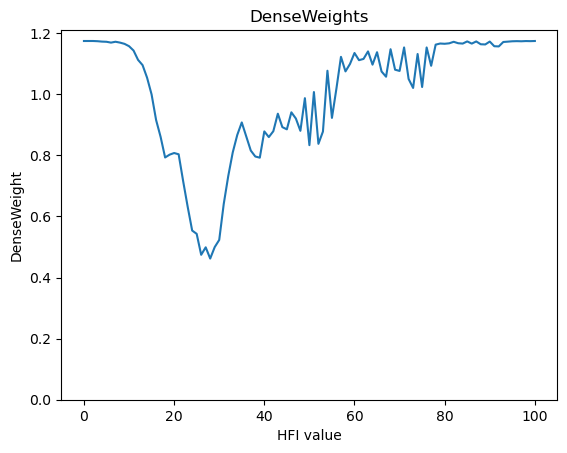

In [5]:
imp.reload(methods)
bins = np.asarray(np.arange(0.0, 101.0, 1.0), dtype="float32")

denseweights = methods.get_denseweights(settings, tags_train)

loss_dual = methods.DenseDualWeightMSE_Loss(
    tf.constant(np.ones(denseweights.shape), dtype="float32"),
    tf.constant(settings["loss_params"], dtype="float32"),
)
loss_total = methods.DenseDualWeightMSE_Loss(
    tf.constant(denseweights, dtype="float32"),
    tf.constant(settings["loss_params"], dtype="float32"),
)

y_dual = [loss_dual(val, val + 1.0).numpy() for val in bins]
y_total = [loss_total(val, val + 1.0).numpy() for val in bins]

plt.title("Sample Weights")
plt.plot(bins, denseweights, label="DenseWeightMSE")
plt.plot(bins, y_dual, label="DualWeightMSE")
plt.plot(bins, y_total, color="k", label="Total: DenseDualWeightMSE")
plt.legend()
plt.xlabel("HFI value")
plt.ylabel("Weights")
plt.ylim(0, None)
plt.show()

In [6]:
# TRAIN THE MODEL
imp.reload(build_model)
imp.reload(train_model)
imp.reload(methods)

tf.keras.backend.clear_session()
model = build_model.build_model(settings, input_shape=(batch_shape[1:]))

settings["mode"] = "training"
model, fit_summary, history, settings = train_model.train_model(
    settings, model, tfds_train, tfds_val, denseweights
)
fit_summary

using loss = <methods.DenseDualWeightMSE_Loss object at 0x2bddeb3a0>
Epoch 1/1000
750/750 [==============================] - 160s 211ms/step - loss: 18.1293 - mae: 11.1987 - val_loss: 19.1713 - val_mae: 10.5483 - lr: 0.0010
Epoch 2/1000
750/750 [==============================] - 163s 217ms/step - loss: 16.9791 - mae: 10.2507 - val_loss: 16.5804 - val_mae: 10.2245 - lr: 0.0010
Epoch 3/1000
750/750 [==============================] - 172s 229ms/step - loss: 16.3959 - mae: 9.9760 - val_loss: 15.9521 - val_mae: 9.6788 - lr: 0.0010
Epoch 4/1000
750/750 [==============================] - 167s 223ms/step - loss: 16.4218 - mae: 10.0358 - val_loss: 15.5214 - val_mae: 9.5070 - lr: 0.0010
Epoch 5/1000
750/750 [==============================] - ETA: 0s - loss: 15.7155 - mae: 9.5902

In [ ]:
print("training complete.")